# Entrega #01 — Análise Exploratória de Dados

## Bootcamp de Ciência de Dados — Avanti

**Equipe:** Squad-01

**Integrantes:**
- Eraldo Cassimiro | ejces@cin.ufpe.br
- Débora Martini | martini.debi@gmail.com
- Luiz Passos | lsps1019@gmail.com
- Douglas Salustiano
- Syonarya Melo

**Conjunto de dados:** Sleep Efficiency

**Fonte:** [Kaggle — Sleep Efficiency Dataset](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)

## Objetivo

Realizar uma análise exploratória do conjunto de dados Sleep Efficiency, investigando os hábitos de sono, as características demográficas e o estilo de vida dos participantes.

A análise busca identificar distribuições, possíveis inconsistências e relações entre as variáveis, especialmente os fatores associados à eficiência do sono.

A variável-alvo é **Sleep efficiency**, caracterizando um problema de aprendizado supervisionado do tipo regressão.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

nome_arquivo = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

Saving Sleep_Efficiency.csv to Sleep_Efficiency (1).csv


## Descrição dos dados

O conjunto de dados **Sleep Efficiency** reúne informações demográficas, hábitos de vida e características do sono de diferentes indivíduos. Cada linha representa um participante e cada coluna descreve uma característica relacionada ao indivíduo ou ao seu período de sono.

A base contém **452 registros e 15 variáveis** e foi disponibilizada no [Kaggle — Sleep Efficiency Dataset](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency).

A variável-alvo é `Sleep efficiency`, que representa a proporção entre o tempo efetivamente dormido e o tempo total passado na cama. Por ser uma variável quantitativa contínua, sua futura previsão caracteriza um problema de regressão.

In [ ]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de variáveis: {df.shape[1]}")

df.info()

Quantidade de registros: 452
Quantidade de variáveis: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null  

In [ ]:
df.columns.tolist()

['ID',
 'Age',
 'Gender',
 'Bedtime',
 'Wakeup time',
 'Sleep duration',
 'Sleep efficiency',
 'REM sleep percentage',
 'Deep sleep percentage',
 'Light sleep percentage',
 'Awakenings',
 'Caffeine consumption',
 'Alcohol consumption',
 'Smoking status',
 'Exercise frequency']

In [ ]:
# Verificação de valores ausentes
valores_ausentes = pd.DataFrame({
    "Quantidade": df.isnull().sum(),
    "Percentual (%)": (df.isnull().mean() * 100).round(2)
})

valores_ausentes = valores_ausentes[
    valores_ausentes["Quantidade"] > 0
]

valores_ausentes

,Quantidade,Percentual (%)
Awakenings,20,4.42
Caffeine consumption,25,5.53
Alcohol consumption,14,3.10
Exercise frequency,6,1.33


In [ ]:
# Verificação de registros duplicados e da variável ID
print(f"Linhas completamente duplicadas: {df.duplicated().sum()}")
print(f"IDs repetidos: {df['ID'].duplicated().sum()}")
print(f"IDs ausentes: {df['ID'].isnull().sum()}")
print(f"Quantidade de IDs únicos: {df['ID'].nunique()}")

Linhas completamente duplicadas: 0
IDs repetidos: 0
IDs ausentes: 0
Quantidade de IDs únicos: 452


### Observações sobre a qualidade dos dados

O conjunto de dados possui **452 registros e 15 variáveis**. Não foram identificadas linhas completamente duplicadas nem valores repetidos na variável `ID`.

Foram encontrados valores ausentes em quatro variáveis:

- `Awakenings`: 20 valores ausentes (4,42%);
- `Caffeine consumption`: 25 valores ausentes (5,53%);
- `Alcohol consumption`: 14 valores ausentes (3,10%);
- `Exercise frequency`: 6 valores ausentes (1,33%).

As demais variáveis estão completamente preenchidas. Neste momento, os registros serão mantidos, pois a remoção ou o preenchimento dos valores ausentes deverá ser decidido conforme as análises realizadas posteriormente.

As variáveis `Bedtime` e `Wakeup time` foram inicialmente importadas como texto (`object`) e deverão ser convertidas para o formato de data e hora antes das análises temporais.

## Dicionário de dados

O dicionário apresenta o significado e a classificação estatística de cada variável do conjunto de dados. Embora `ID` seja armazenada numericamente, ela é classificada como qualitativa nominal, pois funciona apenas como identificador.

In [ ]:
dicionario = pd.DataFrame({
    "variavel": [
        "ID",
        "Age",
        "Gender",
        "Bedtime",
        "Wakeup time",
        "Sleep duration",
        "Sleep efficiency",
        "REM sleep percentage",
        "Deep sleep percentage",
        "Light sleep percentage",
        "Awakenings",
        "Caffeine consumption",
        "Alcohol consumption",
        "Smoking status",
        "Exercise frequency"
    ],

    "descricao": [
        "Identificador único do registro.",
        "Idade do indivíduo em anos.",
        "Gênero do participante.",
        "Horário em que o indivíduo foi para a cama.",
        "Horário em que o indivíduo acordou.",
        "Quantidade total de horas dormidas.",
        "Proporção entre o tempo efetivamente dormido e o tempo total passado na cama.",
        "Porcentagem do sono total passada na fase REM.",
        "Porcentagem do sono total passada na fase de sono profundo.",
        "Porcentagem do sono total passada na fase de sono leve.",
        "Número de despertares durante o período de sono.",
        "Quantidade de cafeína consumida nas 24 horas anteriores ao horário de dormir.",
        "Quantidade de álcool consumida nas 24 horas anteriores ao horário de dormir.",
        "Indica se o indivíduo é fumante ou não.",
        "Quantidade de vezes que o indivíduo pratica exercícios por semana."
    ],

    "tipo": [
        "Qualitativa",
        "Quantitativa",
        "Qualitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Quantitativa",
        "Qualitativa",
        "Quantitativa"
    ],

    "subtipo": [
        "Nominal",
        "Discreta",
        "Nominal",
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Discreta",
        "Contínua",
        "Contínua",
        "Nominal",
        "Discreta"
    ]
})

dicionario

,variavel,descricao,tipo,subtipo
0,ID,Identificador único do registro.,Qualitativa,Nominal
1,Age,Idade do indivíduo em anos.,Quantitativa,Discreta
2,Gender,Gênero do participante.,Qualitativa,Nominal
3,Bedtime,Horário em que o indivíduo foi para a cama.,Quantitativa,Contínua
4,Wakeup time,Horário em que o indivíduo acordou.,Quantitativa,Contínua
5,Sleep duration,Quantidade total de horas dormidas.,Quantitativa,Contínua
6,Sleep efficiency,Proporção entre o tempo efetivamente dormido e...,Quantitativa,Contínua
7,REM sleep percentage,Porcentagem do sono total passada na fase REM.,Quantitativa,Contínua
8,Deep sleep percentage,Porcentagem do sono total passada na fase de s...,Quantitativa,Contínua
9,Light sleep percentage,Porcentagem do sono total passada na fase de s...,Quantitativa,Contínua


### Classificação das variáveis

A variável `ID`, apesar de possuir valores numéricos, foi classificada como qualitativa nominal, pois seus valores apenas identificam os registros e não representam uma medida.

As variáveis `Bedtime` e `Wakeup time` são temporais e foram classificadas como quantitativas contínuas, pois representam horários. Já `Awakenings` e `Exercise frequency` são discretas, pois representam contagens.

A variável-alvo `Sleep efficiency` é quantitativa contínua, justificando o enquadramento do futuro problema de aprendizado supervisionado como uma tarefa de regressão.

## Tratamento das variáveis temporais

As variáveis `Bedtime` e `Wakeup time` foram convertidas do formato textual para data e hora. Nos registros em que o horário de despertar é anterior ao horário de dormir, considera-se que o sono atravessou a meia-noite. Nesses casos, foi acrescentado um dia ao horário de despertar.

In [ ]:
# Conversão para data e hora
df["Bedtime"] = pd.to_datetime(df["Bedtime"])
df["Wakeup time"] = pd.to_datetime(df["Wakeup time"])

# Identificação dos registros que atravessam a meia-noite
cruza_meia_noite = df["Wakeup time"] < df["Bedtime"]

print(f"Registros que atravessam a meia-noite: {cruza_meia_noite.sum()}")

# Correção da data de despertar
df.loc[cruza_meia_noite, "Wakeup time"] += pd.Timedelta(days=1)

df[["Bedtime", "Wakeup time", "Sleep duration"]].head(10)

Registros que atravessam a meia-noite: 211


,Bedtime,Wakeup time,Sleep duration
0,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0
1,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0
2,2021-05-25 21:30:00,2021-05-26 05:30:00,8.0
3,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0
4,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0
5,2021-07-01 21:00:00,2021-07-02 04:30:00,7.5
6,2021-07-21 21:00:00,2021-07-22 03:00:00,6.0
7,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0
8,2021-04-05 02:30:00,2021-04-05 08:30:00,6.0
9,2021-09-16 01:00:00,2021-09-16 10:00:00,9.0


In [ ]:
duracao_calculada = (
    df["Wakeup time"] - df["Bedtime"]
).dt.total_seconds() / 3600

quantidade_compativel = np.isclose(
    duracao_calculada,
    df["Sleep duration"]
).sum()

print(
    f"Durações compatíveis com Sleep duration: "
    f"{quantidade_compativel} de {len(df)}"
)

df[["Bedtime", "Wakeup time"]].dtypes

Durações compatíveis com Sleep duration: 452 de 452


,0
Bedtime,datetime64[ns]
Wakeup time,datetime64[ns]


## Análise univariada

Nesta seção, cada variável é analisada individualmente para compreender sua distribuição, frequência, tendência central, dispersão, presença de valores ausentes e possíveis valores extremos.

In [ ]:
# Seleção das variáveis quantitativas
variaveis_quantitativas = [
    "Age",
    "Sleep duration",
    "Sleep efficiency",
    "REM sleep percentage",
    "Deep sleep percentage",
    "Light sleep percentage",
    "Awakenings",
    "Caffeine consumption",
    "Alcohol consumption",
    "Exercise frequency"
]

# Estatísticas descritivas
estatisticas_quantitativas = (
    df[variaveis_quantitativas]
    .describe()
    .T
    .round(2)
)

estatisticas_quantitativas

,count,mean,std,min,25%,50%,75%,max
Age,452.0,40.29,13.17,9.0,29.00,40.00,52.0,69.00
Sleep duration,452.0,7.47,0.87,5.0,7.00,7.50,8.0,10.00
Sleep efficiency,452.0,0.79,0.14,0.5,0.70,0.82,0.9,0.99
REM sleep percentage,452.0,22.62,3.53,15.0,20.00,22.00,25.0,30.00
Deep sleep percentage,452.0,52.82,15.65,18.0,48.25,58.00,63.0,75.00
Light sleep percentage,452.0,24.56,15.31,7.0,15.00,18.00,32.5,63.00
Awakenings,432.0,1.64,1.36,0.0,1.00,1.00,3.0,4.00
Caffeine consumption,427.0,23.65,30.20,0.0,0.00,25.00,50.0,200.00
Alcohol consumption,438.0,1.17,1.62,0.0,0.00,0.00,2.0,5.00
Exercise frequency,446.0,1.79,1.43,0.0,0.00,2.00,3.0,5.00


### Interpretação das estatísticas descritivas

A idade dos participantes varia de **9 a 69 anos**, com média de **40,29 anos** e mediana de **40 anos**, indicando equilíbrio entre as medidas de tendência central.

A duração média do sono é de **7,47 horas**, com mediana de **7,5 horas**. Metade dos participantes dorme entre **7 e 8 horas**, enquanto os valores variam de **5 a 10 horas**.

A eficiência média do sono é de **0,79 (79%)**, enquanto a mediana é de **0,82 (82%)**. Os resultados variam entre **50% e 99%**. Como a mediana é superior à média, valores mais baixos podem estar reduzindo a média geral.

Em média, o sono é composto por **22,62% de sono REM**, **52,82% de sono profundo** e **24,56% de sono leve**. As porcentagens de sono profundo e leve apresentam maior dispersão que a porcentagem de sono REM.

O número de despertares apresenta média de **1,64** e mediana de **1 despertar**, variando de **0 a 4**. Essa variável possui apenas **432 observações válidas**, devido à existência de 20 valores ausentes.

O consumo de cafeína apresenta grande dispersão, variando de **0 a 200**, com média de **23,65** e mediana de **25**. O valor máximo está bastante distante do terceiro quartil, que é **50**, devendo ser investigado por meio de gráficos.

O consumo de álcool possui mediana igual a **0**, mostrando que pelo menos metade dos registros apresenta consumo nulo. A frequência de exercícios possui média de **1,79 vez por semana** e mediana de **2 vezes**, variando de **0 a 5**.

Os valores mínimos e máximos observados não devem ser considerados erros automaticamente. Histogramas e boxplots serão utilizados para avaliar a distribuição e identificar possíveis valores extremos.

### Distribuição das variáveis quantitativas

A seguir, são apresentados histogramas e boxplots para analisar a distribuição, a concentração dos valores, a assimetria e a presença de possíveis valores extremos nas variáveis quantitativas.

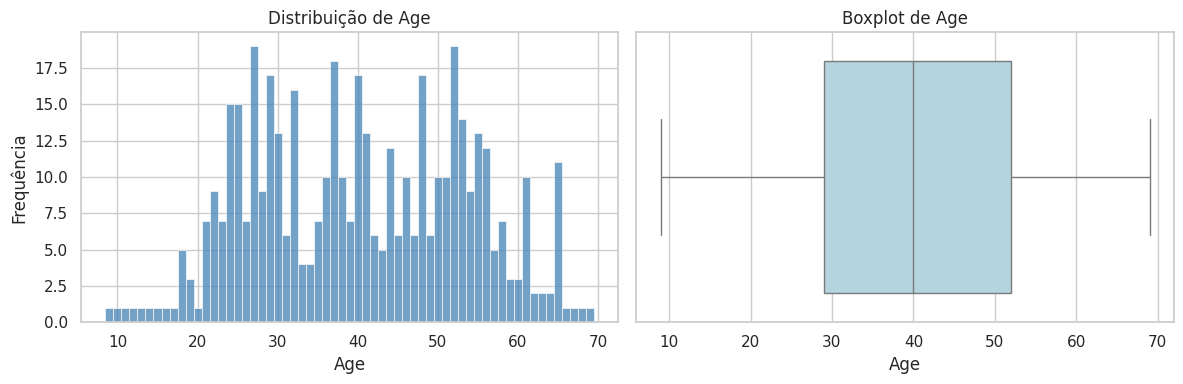

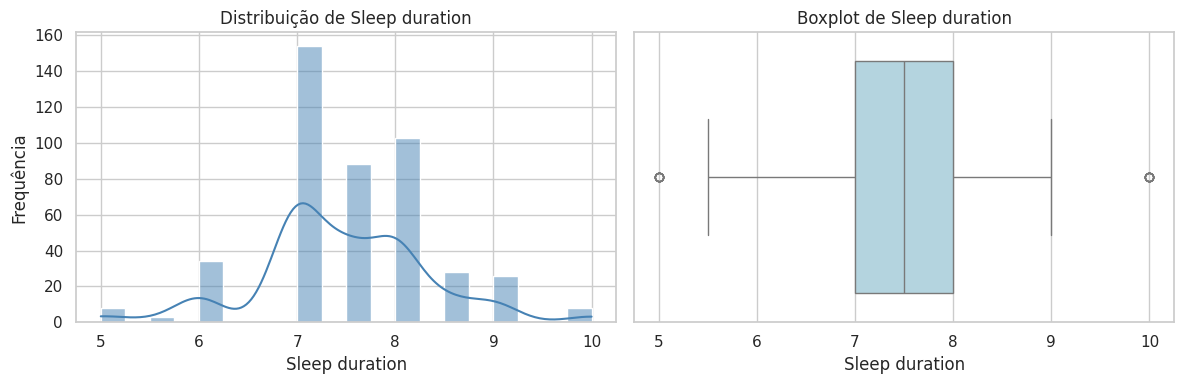

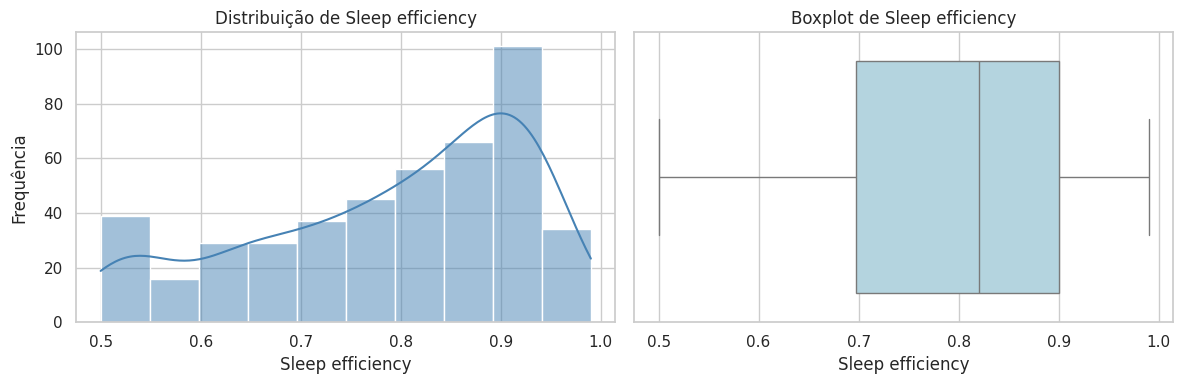

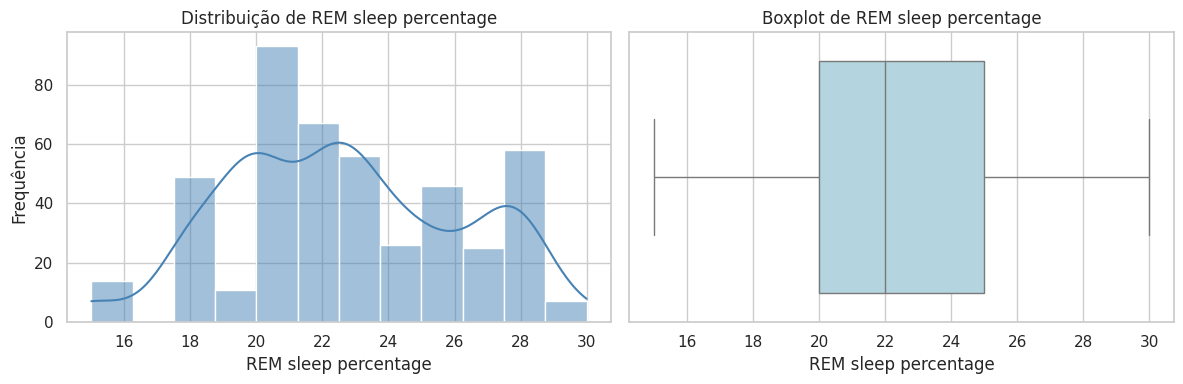

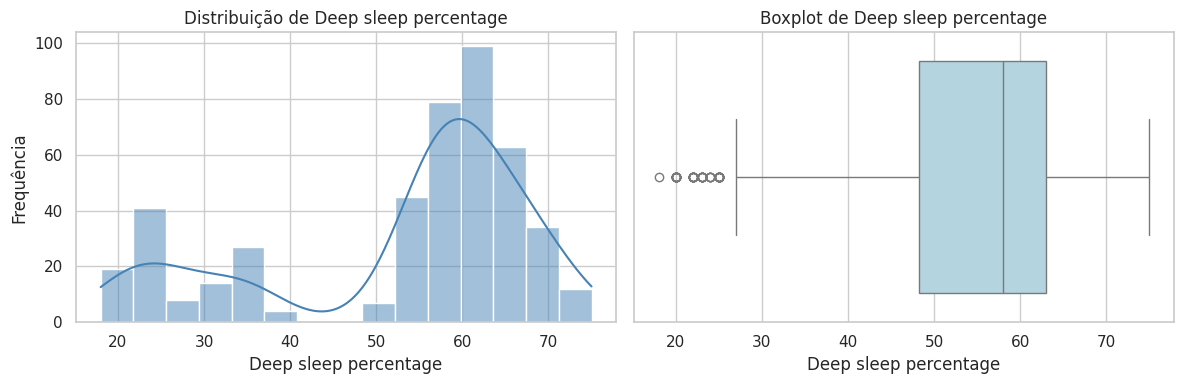

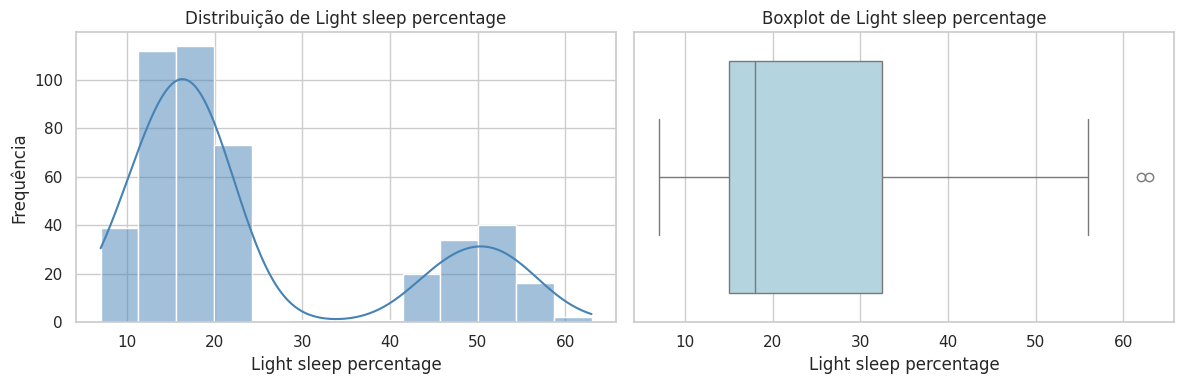

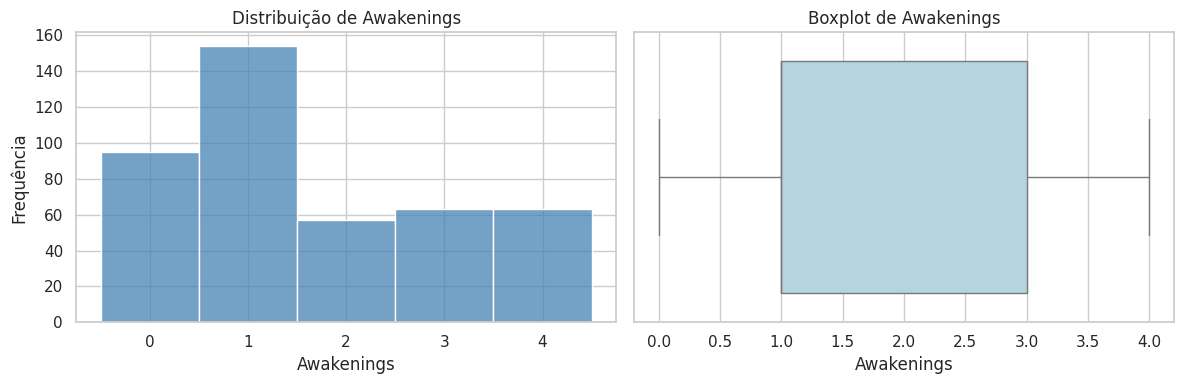

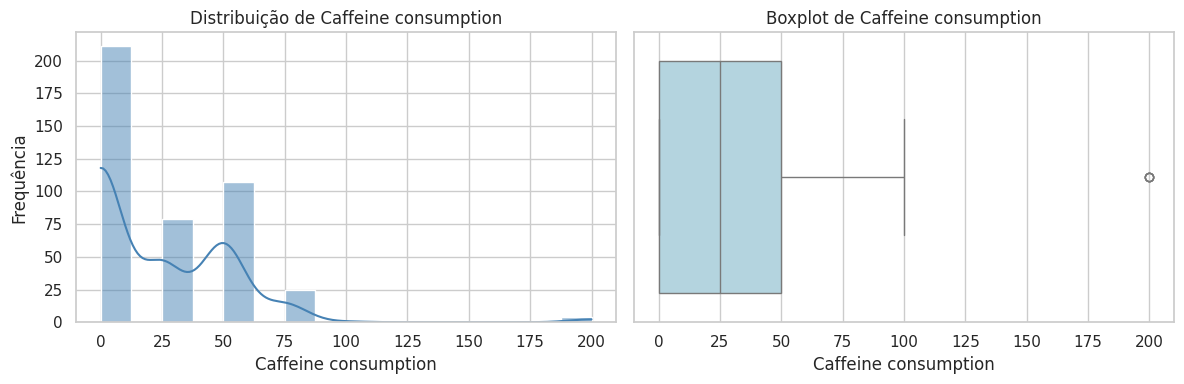

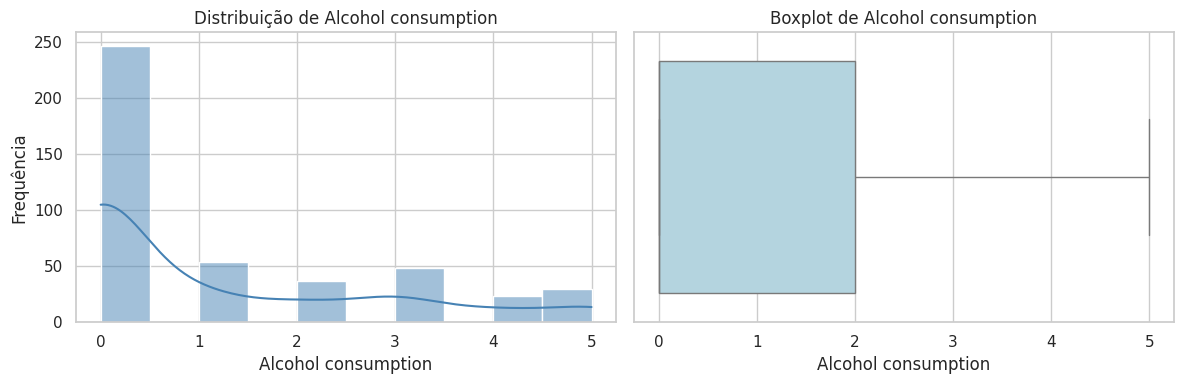

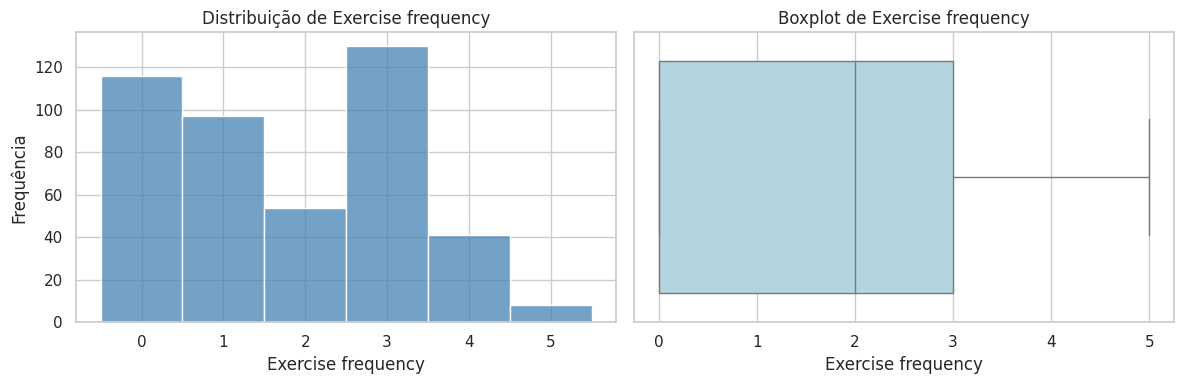

In [ ]:
# Histogramas e boxplots das variáveis quantitativas
variaveis_discretas = [
    "Age",
    "Awakenings",
    "Exercise frequency"
]

for variavel in variaveis_quantitativas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma
    sns.histplot(
        data=df,
        x=variavel,
        bins="auto",
        kde=variavel not in variaveis_discretas,
        discrete=variavel in variaveis_discretas,
        ax=axes[0],
        color="steelblue"
    )

    axes[0].set_title(f"Distribuição de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequência")

    # Boxplot
    sns.boxplot(
        data=df,
        x=variavel,
        ax=axes[1],
        color="lightblue"
    )

    axes[1].set_title(f"Boxplot de {variavel}")
    axes[1].set_xlabel(variavel)

    plt.tight_layout()
    plt.show()

### Interpretação das distribuições quantitativas

- **Age:** as idades variam de 9 a 69 anos, com mediana de 40 anos. A distribuição apresenta participantes de diferentes faixas etárias, sem valores extremos identificados pelo boxplot.

- **Sleep duration:** a maior concentração está entre 7 e 8 horas, com mediana de 7,5 horas. Os valores de 5 e 10 horas foram classificados pelo boxplot como possíveis valores extremos. Entretanto, são durações de sono plausíveis e não representam necessariamente erros.

- **Sleep efficiency:** os valores estão mais concentrados nas maiores eficiências, principalmente entre 0,70 e 0,90. A mediana é de 0,82, equivalente a 82%. A distribuição apresenta uma cauda em direção aos valores menores e não possui outliers evidentes.

- **REM sleep percentage:** a porcentagem de sono REM varia entre 15% e 30%, com mediana de 22%. A distribuição apresenta diferentes concentrações dentro desse intervalo, sem valores extremos no boxplot.

- **Deep sleep percentage:** os dados apresentam dois grupos mais visíveis: um com percentuais menores, aproximadamente entre 18% e 35%, e outro mais concentrado entre 50% e 70%. Alguns valores baixos foram classificados como possíveis outliers, mas a concentração desses registros sugere que podem representar um grupo real da base.

- **Light sleep percentage:** também foi observada uma distribuição com dois agrupamentos, um entre aproximadamente 10% e 25% e outro entre 40% e 60%. Os valores entre 60% e 63% aparecem como possíveis outliers superiores.

- **Awakenings:** o número de despertares varia de 0 a 4, sendo 1 despertar o resultado mais frequente e também a mediana. Não foram identificados valores extremos.

- **Caffeine consumption:** existe forte concentração no consumo igual a zero, seguida principalmente pelos valores 25 e 50. A distribuição possui assimetria à direita, e o valor 200 foi identificado como possível outlier por estar muito distante dos demais.

- **Alcohol consumption:** a maioria dos participantes apresenta consumo igual a zero. Os demais valores diminuem em frequência à medida que o consumo aumenta, formando uma distribuição assimétrica à direita. Não foram identificados outliers pelo boxplot.

- **Exercise frequency:** os valores variam de 0 a 5 vezes por semana. As frequências mais comuns são 0, 1 e 3 vezes, enquanto 5 vezes por semana é pouco frequente. O boxplot não indica valores extremos.

Os valores classificados como outliers não serão removidos automaticamente, pois podem representar observações reais. Uma eventual exclusão exigiria evidências de erro de registro ou justificativa relacionada ao objetivo da análise.

### Distribuição das variáveis qualitativas

As variáveis qualitativas são analisadas por meio das frequências absolutas e percentuais de suas categorias. Também são utilizados gráficos de barras para facilitar a comparação.

In [ ]:
# Seleção das variáveis qualitativas
variaveis_qualitativas = [
    "Gender",
    "Smoking status"
]

# Tabelas de frequência absoluta e percentual
for variavel in variaveis_qualitativas:
    frequencias = pd.DataFrame({
        "Frequência": df[variavel].value_counts(),
        "Percentual (%)": (
            df[variavel]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })

    print(f"\nDistribuição de {variavel}:")
    display(frequencias)


Distribuição de Gender:


,Frequência,Percentual (%)
Gender,,
Male,228,50.44
Female,224,49.56



Distribuição de Smoking status:


,Frequência,Percentual (%)
Smoking status,,
No,298,65.93
Yes,154,34.07


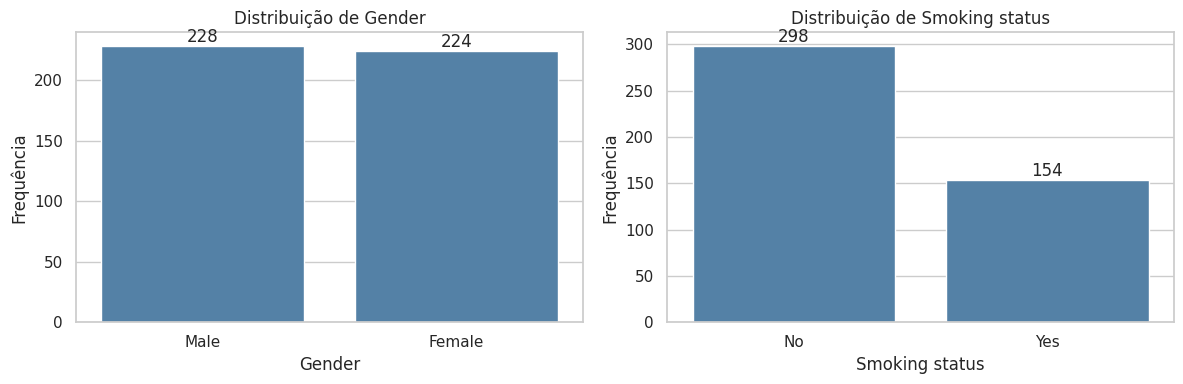

In [ ]:
# Gráficos das variáveis qualitativas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, variavel in zip(axes, variaveis_qualitativas):
    ordem = df[variavel].value_counts().index

    sns.countplot(
        data=df,
        x=variavel,
        order=ordem,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(f"Distribuição de {variavel}")
    ax.set_xlabel(variavel)
    ax.set_ylabel("Frequência")

    # Inclusão dos valores sobre as barras
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretação das variáveis qualitativas

A variável `Gender` apresenta uma distribuição praticamente equilibrada: **228 participantes são do gênero masculino (50,44%)** e **224 são do gênero feminino (49,56%)**. Portanto, não existe desequilíbrio relevante entre essas categorias.

Em relação a `Smoking status`, **298 participantes (65,93%) não são fumantes**, enquanto **154 (34,07%) são fumantes**. Existe predominância de não fumantes, embora a categoria de fumantes ainda represente uma parcela considerável da amostra.

Não foram identificados valores ausentes nessas duas variáveis. Posteriormente, a análise bivariada poderá investigar se a eficiência do sono apresenta diferenças de acordo com o gênero e o hábito de fumar.

### Distribuição dos horários de dormir e acordar

Para a análise univariada das variáveis temporais, foram considerados apenas os horários, desconsiderando as datas dos registros. As frequências permitem identificar os horários mais comuns de dormir e acordar.

Como os horários de dormir atravessam a meia-noite, eles são apresentados em ordem cronológica, começando às 21h e seguindo até os horários da madrugada.

In [ ]:
# Extração dos horários no formato HH:MM
bedtime_horarios = df["Bedtime"].dt.strftime("%H:%M")
wakeup_horarios = df["Wakeup time"].dt.strftime("%H:%M")

# Função para ordenar Bedtime corretamente através da meia-noite
def ordenar_horario_noturno(horario):
    hora, minuto = map(int, horario.split(":"))
    minutos = hora * 60 + minuto
    return (minutos - 12 * 60) % (24 * 60)

ordem_bedtime = sorted(
    bedtime_horarios.unique(),
    key=ordenar_horario_noturno
)

ordem_wakeup = sorted(wakeup_horarios.unique())

# Tabelas de frequência
frequencia_bedtime = (
    bedtime_horarios
    .value_counts()
    .reindex(ordem_bedtime)
    .rename_axis("Horário de dormir")
    .reset_index(name="Frequência")
)

frequencia_wakeup = (
    wakeup_horarios
    .value_counts()
    .reindex(ordem_wakeup)
    .rename_axis("Horário de acordar")
    .reset_index(name="Frequência")
)

display(frequencia_bedtime)
display(frequencia_wakeup)

,Horário de dormir,Frequência
0,21:00,38
1,21:30,35
2,22:00,56
3,22:30,27
4,23:00,55
5,00:00,75
6,00:30,35
7,01:00,35
8,01:30,32
9,02:00,32


,Horário de acordar,Frequência
0,03:00,7
1,03:30,3
2,04:00,19
3,04:30,24
4,05:00,46
5,05:30,34
6,06:00,35
7,06:30,29
8,07:00,46
9,07:30,32


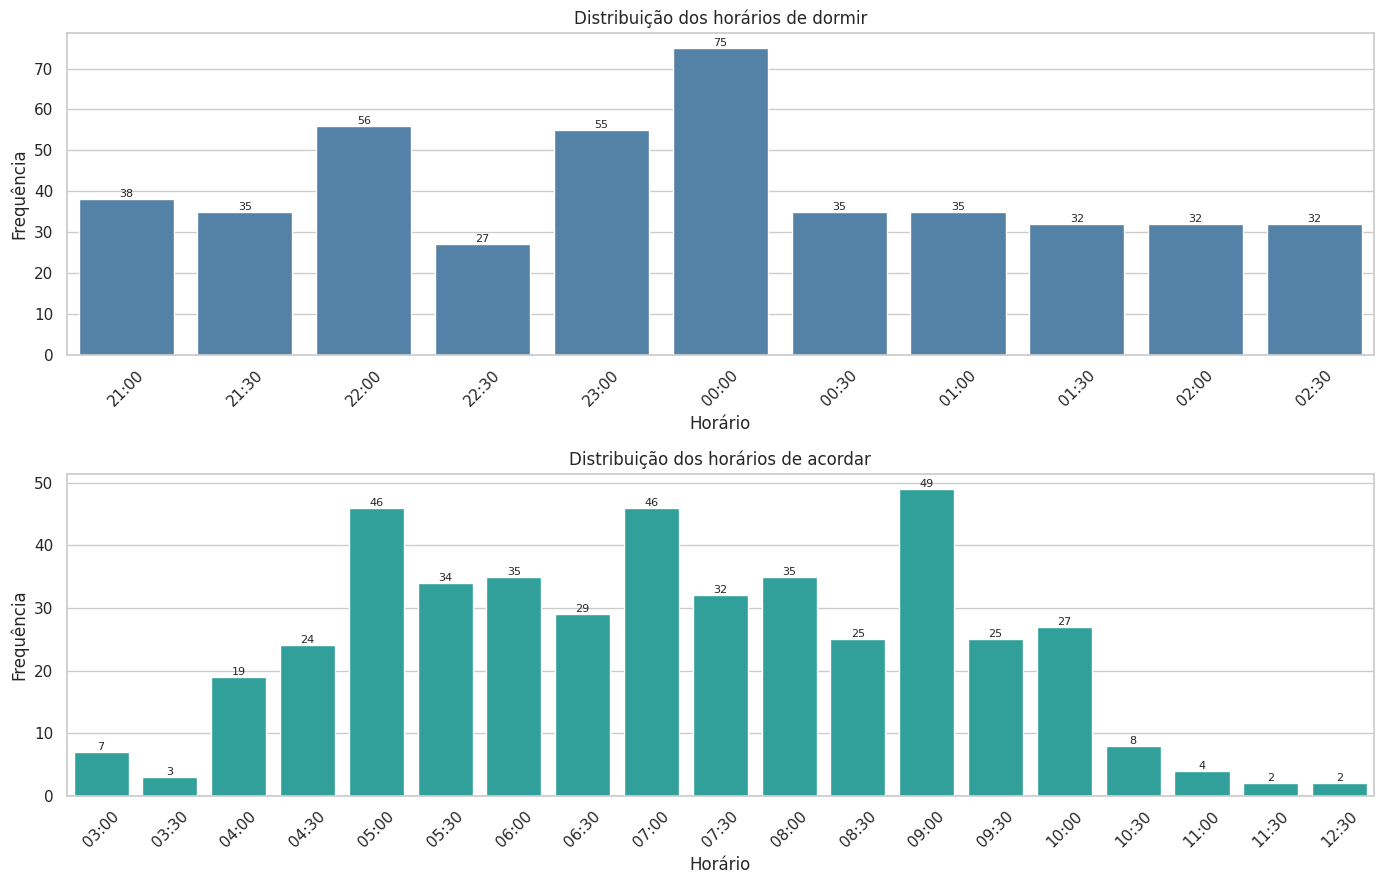

In [ ]:
# Gráficos das frequências dos horários
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.barplot(
    data=frequencia_bedtime,
    x="Horário de dormir",
    y="Frequência",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Distribuição dos horários de dormir")
axes[0].set_xlabel("Horário")
axes[0].set_ylabel("Frequência")

sns.barplot(
    data=frequencia_wakeup,
    x="Horário de acordar",
    y="Frequência",
    color="lightseagreen",
    ax=axes[1]
)

axes[1].set_title("Distribuição dos horários de acordar")
axes[1].set_xlabel("Horário")
axes[1].set_ylabel("Frequência")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

### Interpretação dos horários de dormir e acordar

Os horários de dormir variam entre **21:00 e 02:30**. O horário mais frequente é **00:00**, observado em **75 registros (16,59%)**. Também se destacam os horários de **22:00**, com 56 registros, e **23:00**, com 55 registros.

Os horários de acordar variam entre **03:00 e 12:30**. O horário mais frequente é **09:00**, com **49 registros (10,84%)**, seguido por **05:00** e **07:00**, ambos com 46 registros.

Os resultados demonstram diversidade nos horários de sono dos participantes. As variáveis foram ordenadas considerando a passagem pela meia-noite, permitindo representar corretamente a sequência dos horários noturnos.

Com essa análise, foi concluída a investigação univariada das variáveis quantitativas, qualitativas e temporais do conjunto de dados.

## Análise bivariada e correlação

Nesta seção, são investigadas as relações entre as variáveis quantitativas. O coeficiente de correlação de Pearson é utilizado para medir a direção e a intensidade das relações lineares.

Os valores variam de -1 a 1. Valores próximos de 1 representam correlação positiva, valores próximos de -1 representam correlação negativa e valores próximos de zero indicam ausência de uma relação linear relevante.

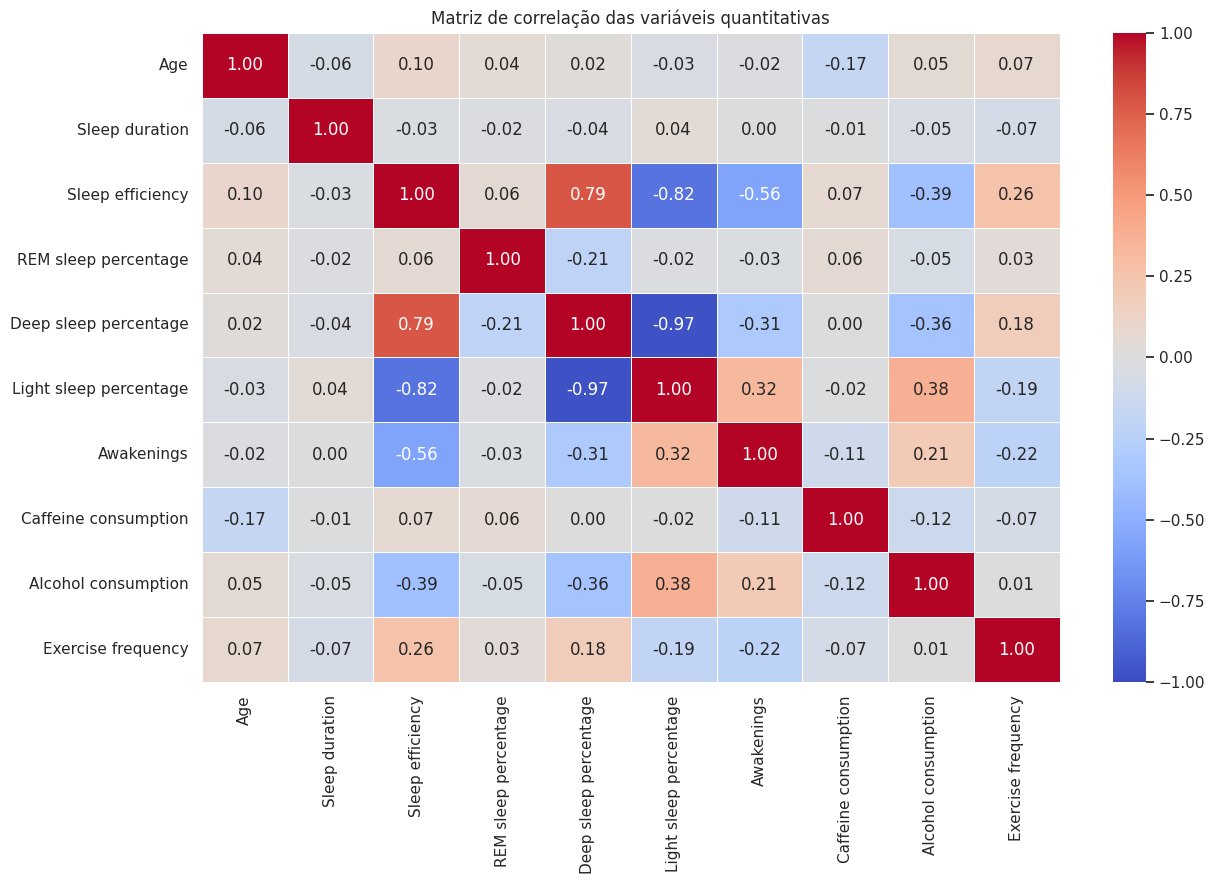

In [ ]:
# Matriz de correlação das variáveis quantitativas
matriz_correlacao = df[variaveis_quantitativas].corr(method="pearson")

plt.figure(figsize=(13, 9))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Matriz de correlação das variáveis quantitativas")
plt.tight_layout()
plt.show()

In [ ]:
# Correlações com a variável-alvo
correlacoes_eficiencia = (
    matriz_correlacao["Sleep efficiency"]
    .drop("Sleep efficiency")
    .sort_values(key=abs, ascending=False)
    .to_frame(name="Correlação com Sleep efficiency")
)

correlacoes_eficiencia

,Correlação com Sleep efficiency
Light sleep percentage,-0.819204
Deep sleep percentage,0.787335
Awakenings,-0.564979
Alcohol consumption,-0.389624
Exercise frequency,0.259563
Age,0.098357
Caffeine consumption,0.065082
REM sleep percentage,0.062362
Sleep duration,-0.027467


### Interpretação das correlações

As correlações mais fortes com `Sleep efficiency` foram observadas nas porcentagens de sono leve e profundo.

- `Light sleep percentage` apresenta correlação negativa forte com a eficiência do sono (**r = -0,82**). Assim, maiores porcentagens de sono leve estão associadas a menores valores de eficiência.
- `Deep sleep percentage` apresenta correlação positiva forte (**r = 0,79**), indicando que maiores porcentagens de sono profundo estão associadas a uma maior eficiência do sono.
- `Awakenings` apresenta correlação negativa moderada (**r = -0,56**). Dessa forma, uma quantidade maior de despertares está associada a uma eficiência menor.
- `Alcohol consumption` apresenta correlação negativa de intensidade fraca a moderada (**r = -0,39**).
- `Exercise frequency` apresenta correlação positiva fraca (**r = 0,26**).

As variáveis `Age`, `Caffeine consumption`, `REM sleep percentage` e `Sleep duration` apresentaram correlações lineares muito fracas com a eficiência do sono.

Destaca-se que `Sleep duration` apresentou correlação próxima de zero (**r = -0,03**). Isso indica que, neste conjunto de dados, dormir por mais tempo não está necessariamente associado a uma maior eficiência do sono.

Também foi identificada uma correlação negativa muito forte entre `Deep sleep percentage` e `Light sleep percentage` (**r = -0,97**). Esse resultado é esperado, pois as porcentagens das fases REM, profunda e leve compõem o total do sono. Portanto, o aumento da participação de uma fase tende a reduzir a participação das demais.

Esses resultados representam associações lineares observadas na amostra e não demonstram relações de causa e efeito.

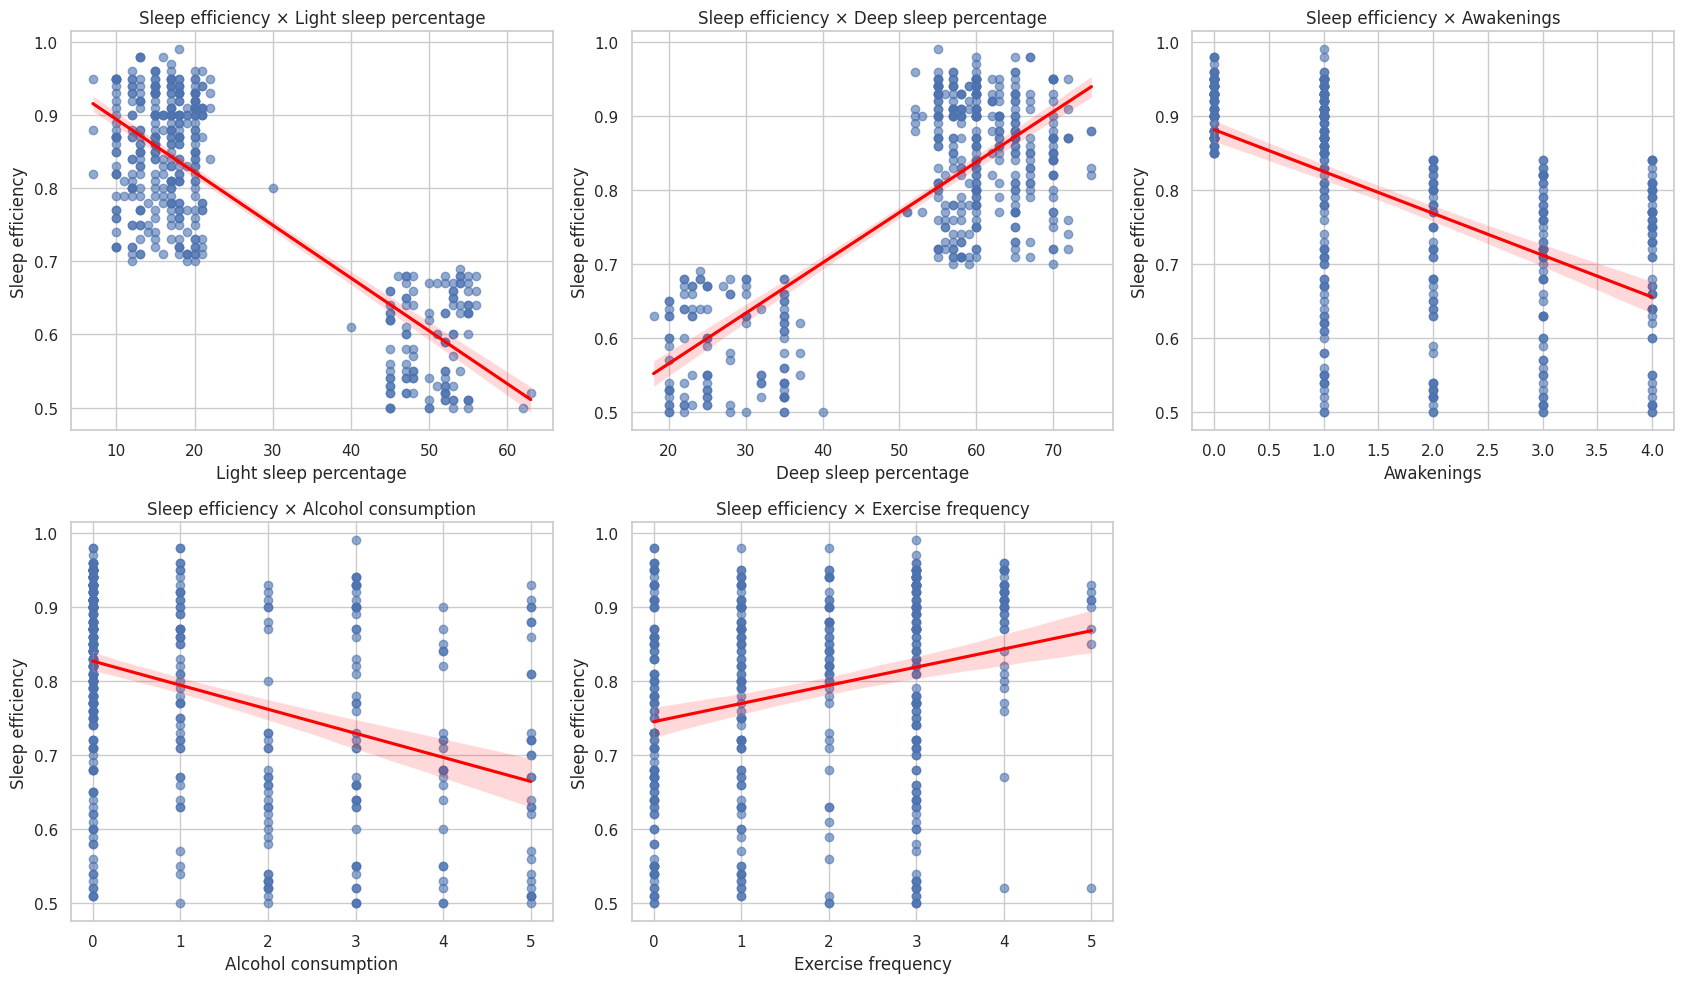

In [ ]:
# Relações das principais variáveis com Sleep efficiency
principais_variaveis = [
    "Light sleep percentage",
    "Deep sleep percentage",
    "Awakenings",
    "Alcohol consumption",
    "Exercise frequency"
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for ax, variavel in zip(axes, principais_variaveis):
    sns.regplot(
        data=df,
        x=variavel,
        y="Sleep efficiency",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
        ax=ax
    )

    ax.set_title(f"Sleep efficiency × {variavel}")
    ax.set_xlabel(variavel)
    ax.set_ylabel("Sleep efficiency")

# Remove o espaço não utilizado
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretação gráfica das principais relações

Os gráficos confirmam visualmente as direções identificadas na matriz de correlação. A eficiência do sono diminui à medida que aumenta a porcentagem de sono leve e aumenta conforme cresce a porcentagem de sono profundo.

Também se observa uma tendência de menor eficiência entre participantes com maior número de despertares e maior consumo de álcool. Em sentido contrário, a frequência de exercícios apresenta associação positiva com a eficiência, embora essa relação seja menos intensa.

Nas porcentagens de sono leve e profundo, são visíveis agrupamentos de observações, coerentes com as distribuições identificadas na análise univariada. Como as fases do sono compõem conjuntamente o total do período dormido, essas relações devem ser interpretadas com cautela.

As linhas de regressão representam tendências médias. A dispersão dos pontos mostra que outros fatores também podem estar associados à eficiência do sono. Portanto, os gráficos demonstram associações, mas não comprovam causalidade.

### Eficiência do sono por variáveis qualitativas

A eficiência do sono é comparada entre as categorias de gênero e hábito de fumar. Para isso, são utilizadas estatísticas descritivas agrupadas e boxplots.

In [ ]:
# Estatísticas da eficiência do sono por categoria
for variavel in ["Gender", "Smoking status"]:
    resumo = (
        df.groupby(variavel)["Sleep efficiency"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(3)
    )

    print(f"\nSleep efficiency por {variavel}:")
    display(resumo)


Sleep efficiency por Gender:


,count,mean,median,std,min,max
Gender,,,,,,
Female,224,0.788,0.815,0.142,0.5,0.98
Male,228,0.790,0.830,0.129,0.5,0.99



Sleep efficiency por Smoking status:


,count,mean,median,std,min,max
Smoking status,,,,,,
No,298,0.817,0.84,0.109,0.52,0.99
Yes,154,0.734,0.78,0.162,0.50,0.97


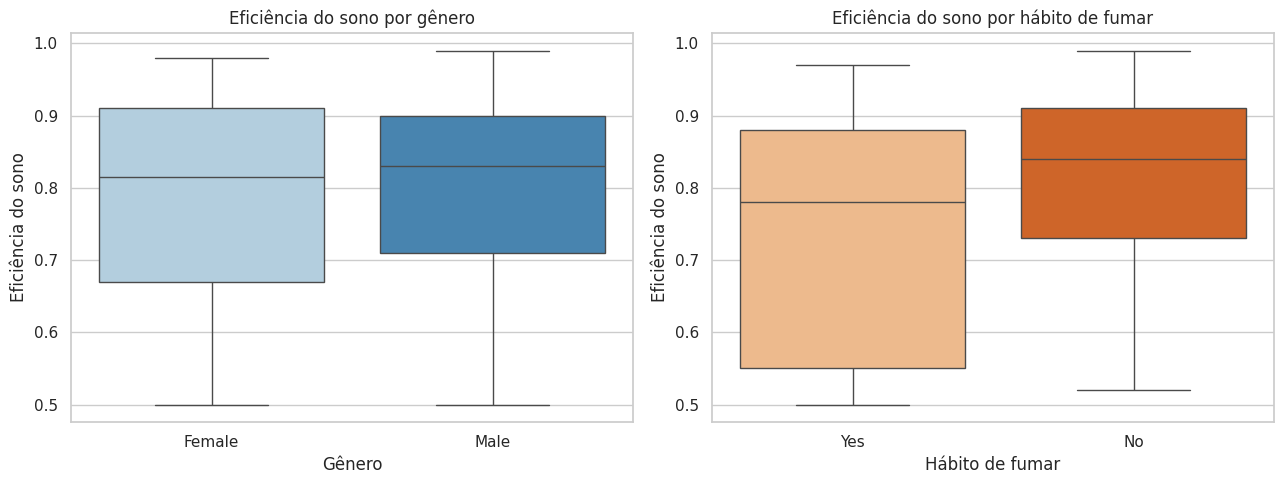

In [ ]:
# Boxplots da eficiência do sono por categoria
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Sleep efficiency",
    hue="Gender",
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Eficiência do sono por gênero")
axes[0].set_xlabel("Gênero")
axes[0].set_ylabel("Eficiência do sono")

sns.boxplot(
    data=df,
    x="Smoking status",
    y="Sleep efficiency",
    hue="Smoking status",
    palette="Oranges",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Eficiência do sono por hábito de fumar")
axes[1].set_xlabel("Hábito de fumar")
axes[1].set_ylabel("Eficiência do sono")

plt.tight_layout()
plt.show()

### Interpretação da eficiência do sono por categoria

A eficiência do sono apresentou resultados muito semelhantes entre os gêneros. O gênero feminino apresentou média de **0,788 (78,8%)** e mediana de **0,815 (81,5%)**, enquanto o masculino apresentou média de **0,790 (79,0%)** e mediana de **0,830 (83,0%)**. Portanto, não foi observada diferença relevante entre os grupos.

Em relação ao hábito de fumar, os não fumantes apresentaram eficiência média de **0,817 (81,7%)**, enquanto os fumantes apresentaram média de **0,734 (73,4%)**. A diferença entre as médias foi de aproximadamente **8,3 pontos percentuais**.

A mediana também foi maior entre os não fumantes: **84%**, em comparação com **78%** entre os fumantes. Além disso, os fumantes apresentaram maior dispersão dos resultados, com desvio padrão de **0,162**, contra **0,109** entre os não fumantes.

Os resultados indicam que, nesta amostra, o hábito de fumar está associado a uma menor eficiência do sono e a uma maior variabilidade dos resultados. Entretanto, essa associação não comprova que o hábito de fumar seja a causa direta da menor eficiência, pois outros fatores também podem influenciar o sono.

## Análise multivariada

Nesta seção, são investigadas simultaneamente três ou mais variáveis, buscando compreender como diferentes características demográficas, hábitos e aspectos do sono se relacionam com a eficiência do sono.

As análises possuem caráter exploratório e representam associações observadas na amostra, não permitindo estabelecer relações de causa e efeito.

In [ ]:
# Preparação dos dados para a análise multivariada
dados_multi = df.dropna(subset=["Awakenings"]).copy()
dados_multi["Awakenings"] = dados_multi["Awakenings"].astype(int)

# Resumo combinando quatro variáveis
resumo_multivariado = (
    dados_multi
    .groupby(
        ["Gender", "Smoking status", "Awakenings"],
        observed=True
    )["Sleep efficiency"]
    .agg(
        Quantidade="count",
        Média="mean",
        Mediana="median"
    )
    .reset_index()
)

resumo_multivariado[["Média", "Mediana"]] = (
    resumo_multivariado[["Média", "Mediana"]].round(3)
)

resumo_multivariado

,Gender,Smoking status,Awakenings,Quantidade,Média,Mediana
0,Female,No,0,42,0.921,0.930
1,Female,No,1,58,0.846,0.885
2,Female,No,2,16,0.706,0.690
3,Female,No,3,19,0.705,0.720
4,Female,No,4,21,0.737,0.760
5,Female,Yes,0,10,0.890,0.890
6,Female,Yes,1,21,0.752,0.800
7,Female,Yes,2,12,0.593,0.540
8,Female,Yes,3,7,0.629,0.570
9,Female,Yes,4,8,0.581,0.535


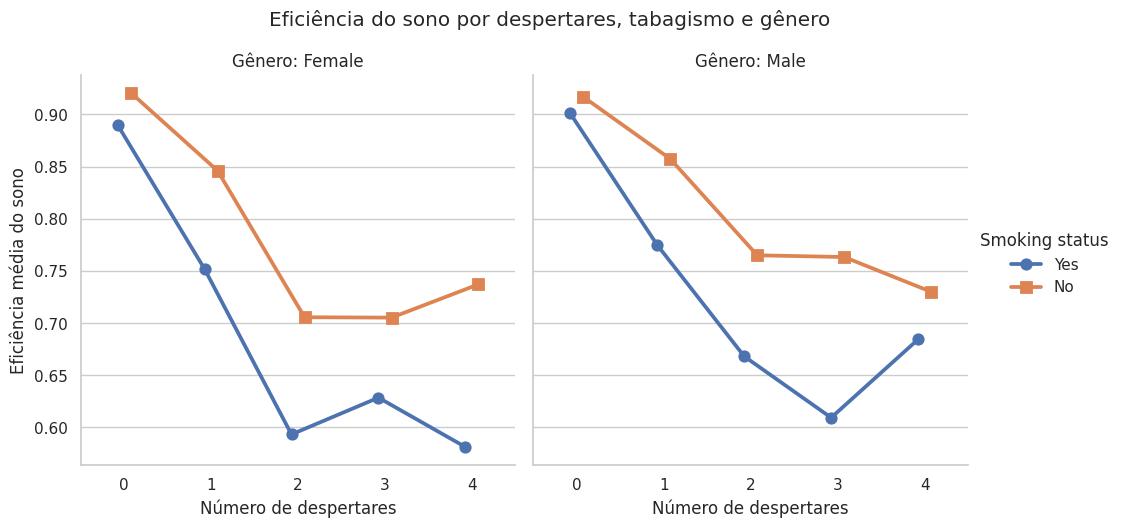

In [ ]:
g = sns.catplot(
    data=dados_multi,
    x="Awakenings",
    y="Sleep efficiency",
    hue="Smoking status",
    col="Gender",
    kind="point",
    dodge=0.15,
    errorbar=None,
    markers=["o", "s"],
    height=5,
    aspect=1
)

g.set_axis_labels(
    "Número de despertares",
    "Eficiência média do sono"
)

g.set_titles("Gênero: {col_name}")
g.fig.suptitle(
    "Eficiência do sono por despertares, tabagismo e gênero",
    y=1.05
)

plt.show()

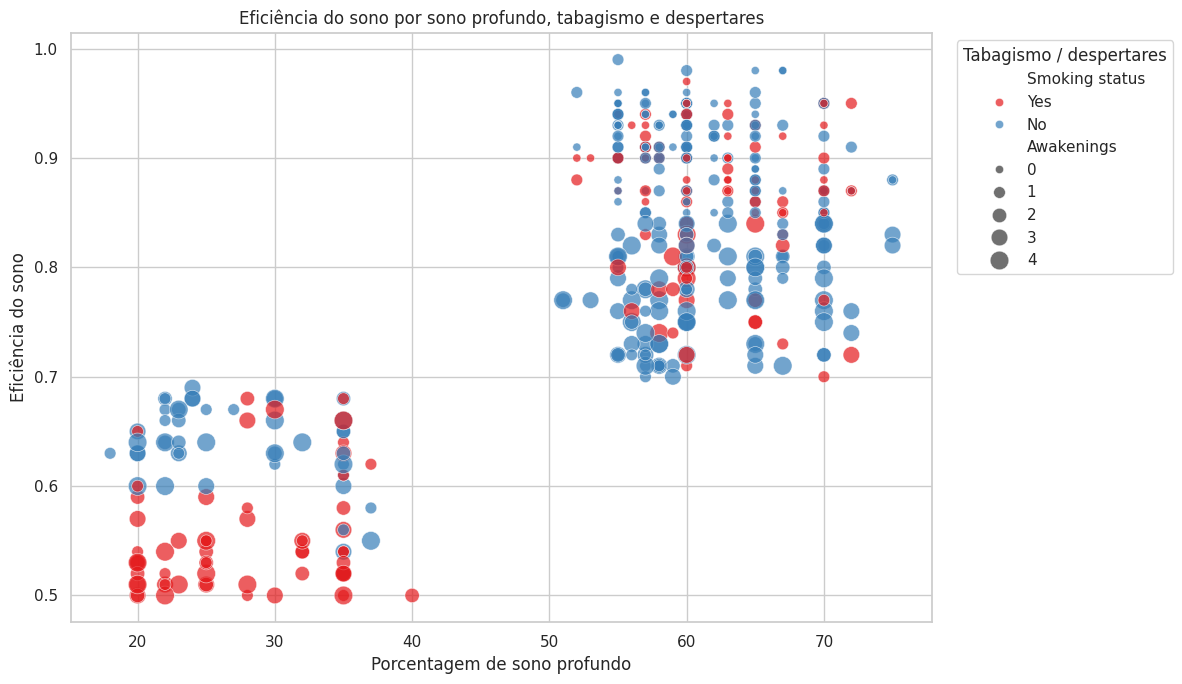

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=dados_multi,
    x="Deep sleep percentage",
    y="Sleep efficiency",
    hue="Smoking status",
    size="Awakenings",
    sizes=(35, 180),
    alpha=0.7,
    palette="Set1"
)

plt.title(
    "Eficiência do sono por sono profundo, tabagismo e despertares"
)
plt.xlabel("Porcentagem de sono profundo")
plt.ylabel("Eficiência do sono")
plt.legend(
    title="Tabagismo / despertares",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretação da análise multivariada

A análise conjunta de gênero, tabagismo, número de despertares e eficiência do sono mostra que a eficiência tende a diminuir conforme aumenta a quantidade de despertares. Essa redução aparece tanto entre homens quanto entre mulheres.

Em praticamente todas as combinações analisadas, os não fumantes apresentam eficiência média superior à dos fumantes com o mesmo gênero e número de despertares. Entre os participantes sem despertares, entretanto, as diferenças são menores, com médias próximas ou superiores a 89% em todos os grupos.

As diferenças tornam-se mais visíveis a partir de um despertar. Entre as mulheres fumantes, por exemplo, a eficiência média diminui de 89,0%, quando não há despertares, para 58,1%, quando existem quatro despertares. Entre os homens fumantes, a média varia de 90,1% para 68,4% nessas mesmas condições.

Não foi identificado um comportamento muito diferente entre os gêneros. Em geral, as variações relacionadas ao número de despertares e ao hábito de fumar parecem mais expressivas que as diferenças entre homens e mulheres.

O segundo gráfico confirma a associação positiva entre a porcentagem de sono profundo e a eficiência do sono. Os participantes com maiores porcentagens de sono profundo tendem a apresentar maiores valores de eficiência. Também é possível observar maior presença de fumantes nos grupos de menor eficiência e menor porcentagem de sono profundo.

O tamanho dos pontos representa o número de despertares. De maneira geral, os pontos maiores aparecem com maior frequência em níveis inferiores de eficiência, reforçando a associação negativa entre despertares e eficiência do sono.

Alguns grupos da tabela possuem poucas observações, como mulheres fumantes com três despertares, que apresentam apenas sete registros. Por isso, pequenas oscilações nas médias entre quantidades consecutivas de despertares devem ser interpretadas com cautela.

Os resultados sugerem que sono profundo, número de despertares e hábito de fumar estão conjuntamente associados à eficiência do sono. Entretanto, a análise é exploratória e não permite afirmar que essas características sejam causas diretas das diferenças observadas.

## Conclusões gerais

A análise exploratória foi realizada com **452 registros** e permitiu compreender as características dos participantes, seus hábitos e os principais fatores associados à eficiência do sono.

A amostra apresenta distribuição equilibrada entre os gêneros, com idades entre **9 e 69 anos**. A duração média do sono foi de **7,47 horas**, enquanto a eficiência média foi de aproximadamente **79%**. O horário mais frequente para dormir foi **00:00**, e o horário mais comum para acordar foi **09:00**.

As associações mais fortes com a eficiência do sono foram encontradas nas fases do sono. A porcentagem de sono leve apresentou correlação negativa forte (**r = -0,82**), enquanto a porcentagem de sono profundo apresentou correlação positiva forte (**r = 0,79**). Também foi observada associação negativa moderada entre o número de despertares e a eficiência (**r = -0,56**).

O consumo de álcool apresentou associação negativa com a eficiência do sono (**r = -0,39**), enquanto a frequência de exercícios apresentou associação positiva, porém mais fraca (**r = 0,26**). A duração do sono, por sua vez, apresentou correlação próxima de zero, indicando que dormir por mais tempo não esteve necessariamente associado a uma maior eficiência nesta amostra.

Não foram observadas diferenças relevantes de eficiência entre os gêneros. Entretanto, os não fumantes apresentaram eficiência média de **81,7%**, enquanto os fumantes apresentaram média de **73,4%**, uma diferença aproximada de **8,3 pontos percentuais**.

A análise multivariada reforçou que o número de despertares, o hábito de fumar e a porcentagem de sono profundo estão conjuntamente associados à eficiência do sono. Em geral, participantes com menos despertares, maior porcentagem de sono profundo e que não fumam apresentaram melhores resultados. As diferenças relacionadas ao gênero foram menos expressivas.

Os possíveis valores extremos identificados, como duração do sono de 5 ou 10 horas e consumo de cafeína igual a 200, não foram removidos, pois são valores plausíveis e não existem evidências suficientes de erro de registro.

### Limitações da análise

Algumas variáveis apresentam valores ausentes, especialmente `Awakenings`, `Caffeine consumption`, `Alcohol consumption` e `Exercise frequency`. Além disso, determinados grupos da análise multivariada possuem poucas observações, exigindo cautela na interpretação de suas médias.

As porcentagens de sono REM, profundo e leve são matematicamente dependentes, pois compõem o total do sono. Isso ajuda a explicar a forte correlação negativa entre as porcentagens de sono profundo e leve.

Por se tratar de uma análise observacional e exploratória, os resultados demonstram associações, mas não permitem estabelecer relações de causa e efeito. Também não é possível garantir que a amostra represente toda a população.

### Possíveis etapas futuras

Como continuidade, podem ser realizados testes estatísticos para avaliar a significância das diferenças entre os grupos, além da construção de modelos de regressão ou aprendizado de máquina para estimar a eficiência do sono. Também seria relevante investigar possíveis interações entre tabagismo, consumo de álcool, exercícios, despertares e fases do sono.